In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

# LOADING DATASET

In [6]:
import pandas as pd
import numpy as np

# URL of Boston dataset
data_url = "http://lib.stat.cmu.edu/datasets/boston"

# Load raw data
raw_df = pd.read_csv(
    data_url,
    sep=r"\s+",
    skiprows=22,
    header=None
)

# Prepare features
data = np.hstack([
    raw_df.values[::2, :],
    raw_df.values[1::2, :2]
])

# Prepare target
target = raw_df.values[1::2, 2]

# Feature names
feature_names = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX",
    "RM", "AGE", "DIS", "RAD", "TAX",
    "PTRATIO", "B", "LSTAT"
]

# Create dataframe
df = pd.DataFrame(data, columns=feature_names)

# Add target column
df["PRICE"] = target

print(df.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  PRICE  
0     15.3  396.90   4.98   24.0  
1     17.8  396.90   9.14   21.6  
2     17.8  392.83   4.03   34.7  
3     18.7  394.63   2.94   33.4  
4     18.7  396.90   5.33   36.2  


In [8]:
df.keys()

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'PRICE'],
      dtype='object')

In [9]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [11]:
df.shape

(506, 14)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  PRICE    506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


In [14]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64

In [15]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


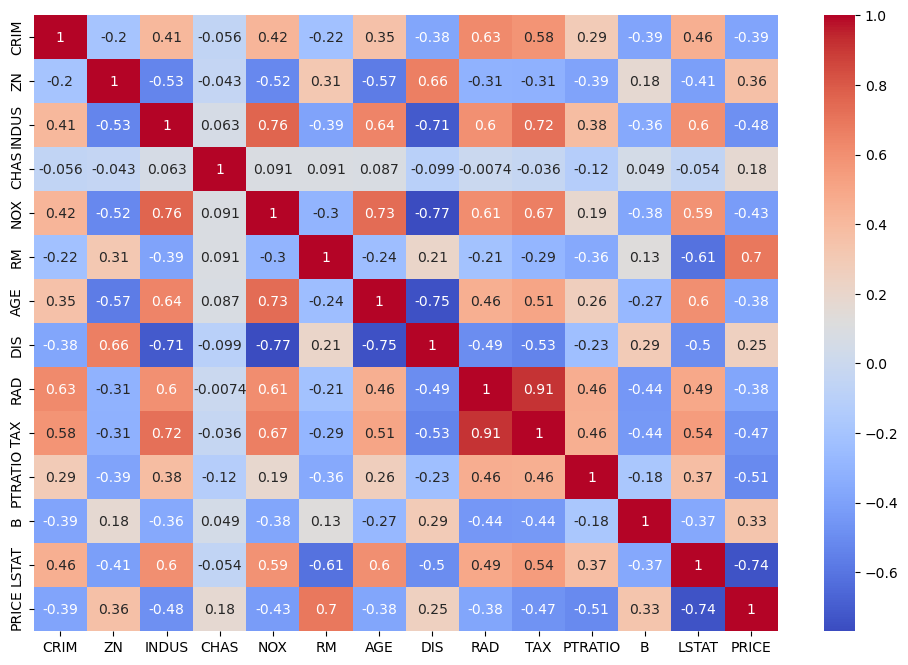

In [16]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [17]:
X = df.drop("PRICE", axis=1)

y = df["PRICE"]

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
y_pred = lr.predict(X_test)

In [23]:
y_pred

array([28.99672362, 36.02556534, 14.81694405, 25.03197915, 18.76987992,
       23.25442929, 17.66253818, 14.34119   , 23.01320703, 20.63245597,
       24.90850512, 18.63883645, -6.08842184, 21.75834668, 19.23922576,
       26.19319733, 20.64773313,  5.79472718, 40.50033966, 17.61289074,
       27.24909479, 30.06625441, 11.34179277, 24.16077616, 17.86058499,
       15.83609765, 22.78148106, 14.57704449, 22.43626052, 19.19631835,
       22.43383455, 25.21979081, 25.93909562, 17.70162434, 16.76911711,
       16.95125411, 31.23340153, 20.13246729, 23.76579011, 24.6322925 ,
       13.94204955, 32.25576301, 42.67251161, 17.32745046, 27.27618614,
       16.99310991, 14.07009109, 25.90341861, 20.29485982, 29.95339638,
       21.28860173, 34.34451856, 16.04739105, 26.22562412, 39.53939798,
       22.57950697, 18.84531367, 32.72531661, 25.0673037 , 12.88628956,
       22.68221908, 30.48287757, 31.52626806, 15.90148607, 20.22094826,
       16.71089812, 20.52384893, 25.96356264, 30.61607978, 11.59

In [24]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)  #Average prediction error, Lower is better.
print("MSE:", mse)  #Punishes large errors heavily.
print("RMSE:", rmse) #Most interpretable error metric.
print("R2 Score:", r2) #how much variance model explains

MAE: 3.1890919658878594
MSE: 24.291119474973655
RMSE: 4.92860218266535
R2 Score: 0.6687594935356301


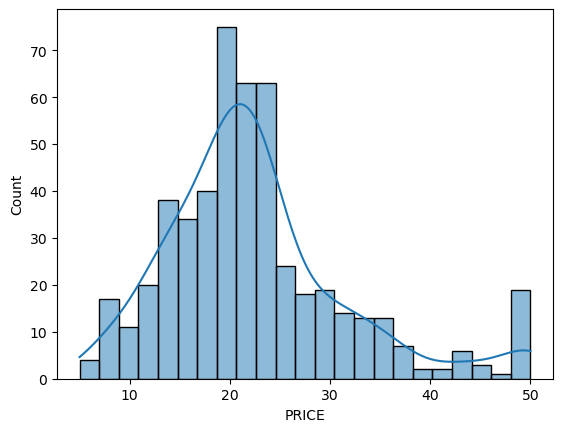

In [25]:
sns.histplot(df["PRICE"], kde=True)

plt.show() #to check skewness, ND, Outliers

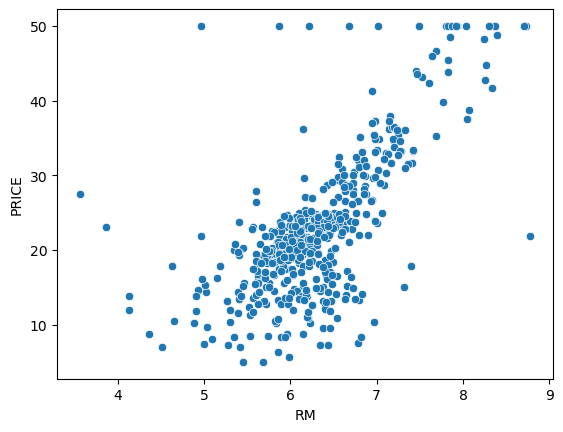

In [26]:
sns.scatterplot(x=df["RM"], y=df["PRICE"])

plt.show() #Visualize relationship, More rooms → higher price.

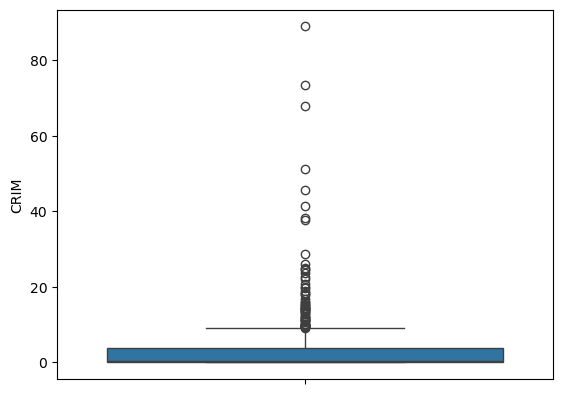

In [28]:
sns.boxplot(df["CRIM"])

plt.show() #Detect outliers, Outliers can hurt Linear Regression badly.

In [31]:
df["CRIM"] = np.log1p(df["CRIM"]) 

#normalizes data improves regression learning

In [33]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

In [36]:
X_poly.shape

(506, 105)

In [37]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print(r2_score(y_test, rf_pred))

0.8839525117021145


In [38]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=5
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': None, 'n_estimators': 100}


In [39]:
from sklearn.linear_model import LinearRegression #Baseline/simple model
from sklearn.ensemble import RandomForestRegressor #Learns nonlinear patterns
from sklearn.tree import DecisionTreeRegressor     #Powerful ensemble model

In [40]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [42]:
lr = LinearRegression()

dt = DecisionTreeRegressor(random_state=42)

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [43]:
lr.fit(X_train, y_train)

dt.fit(X_train, y_train)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [44]:
lr_pred = lr.predict(X_test)

dt_pred = dt.predict(X_test)

rf_pred = rf.predict(X_test)

In [46]:
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression R2 Score:", lr_r2)

Linear Regression R2 Score: 0.6687594935356301


In [47]:
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree R2 Score:", dt_r2)

Decision Tree R2 Score: 0.8579634380978161


In [48]:
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest R2 Score:", rf_r2)

Random Forest R2 Score: 0.8839525117021145


In [49]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "R2 Score": [
        lr_r2,
        dt_r2,
        rf_r2
    ]
})

In [50]:
results

,Model,R2 Score
0,Linear Regression,0.668759
1,Decision Tree,0.857963
2,Random Forest,0.883953


In [52]:
mae = mean_absolute_error(y_test, rf_pred)

mse = mean_squared_error(y_test, rf_pred)

rmse = np.sqrt(mse)

In [59]:
print("MAE", mae)
print("MSE", mse)
print("RMSE", rmse)

MAE 2.0413137254901943
MSE 8.510201343137249
RMSE 2.917224938728114


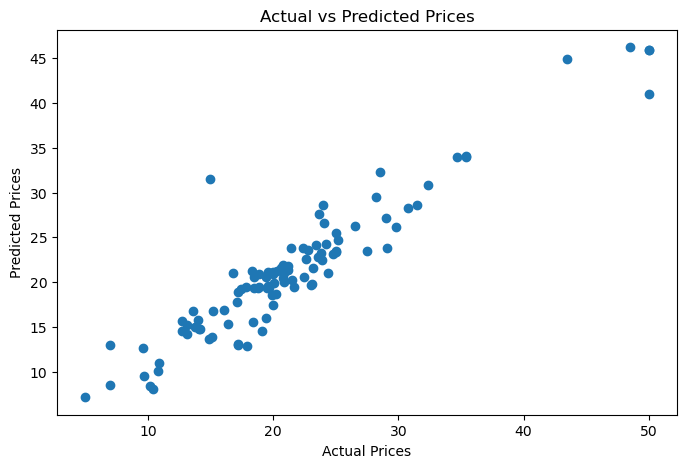

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Prices")

plt.show()

In [62]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

    Feature  Importance
5        RM    0.492309
12    LSTAT    0.323469
7       DIS    0.056308
0      CRIM    0.038540
4       NOX    0.015979
10  PTRATIO    0.015956
9       TAX    0.015470
6       AGE    0.015199
11        B    0.012431
2     INDUS    0.007021
8       RAD    0.004135
1        ZN    0.001891
3      CHAS    0.001292


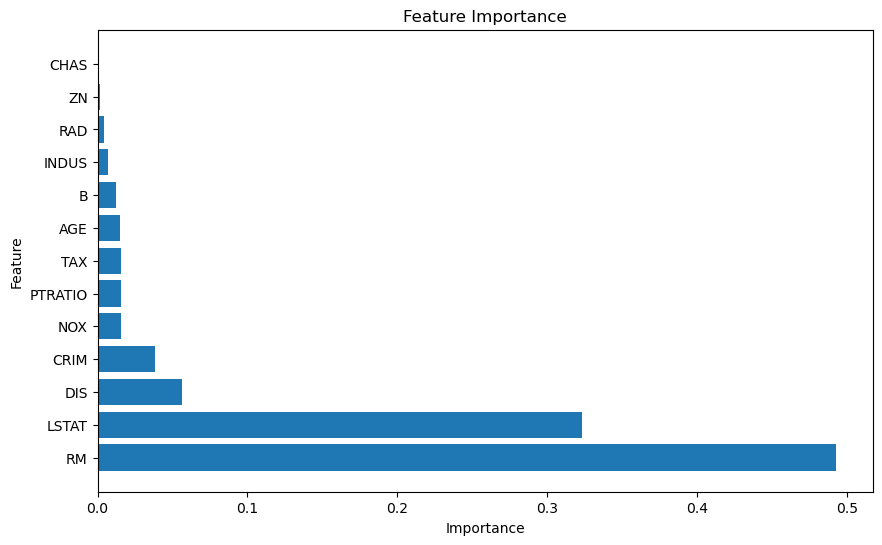

In [63]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("Feature Importance")

plt.show()

In [84]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [85]:
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [86]:
rf.predict(X_test[:5])

array([22.8235, 30.814 , 16.8215, 23.5325, 16.8455])

In [87]:
joblib.dump(rf, "house_price_model.joblib")

['house_price_model.joblib']

In [91]:
loaded_model = joblib.load(
    "house_price_model.joblib"
)

In [93]:
loaded_model.predict(X_test[:5])

array([22.8235, 30.814 , 16.8215, 23.5325, 16.8455])